Competition description

Twitter has become an important communication channel in times of emergency. The ubiquitousness of smartphones enables people to announce an emergency they’re observing in real-time. Because of this, more agencies are interested in programatically monitoring Twitter (i.e. disaster relief organizations and news agencies).

But, it’s not always clear whether a person’s words are actually announcing a disaster.

Acknowledgments

This dataset was created by the company figure-eight and originally shared on their ‘Data For Everyone’ website here.



Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import re
import string

Load csv files

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


Read files

In [3]:
train  = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
test = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')
submission = pd.read_csv('/kaggle/input/nlp-getting-started/sample_submission.csv')

In [4]:
train

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [5]:
test

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


In [6]:
submission

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0
...,...,...
3258,10861,0
3259,10865,0
3260,10868,0
3261,10874,0


Analyse train

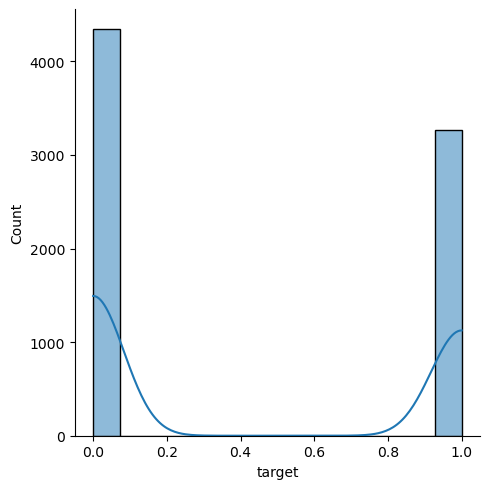

In [7]:
sns.displot(train['target'], kde=True)

In [8]:
train['target'].value_counts()

0    4342
1    3271
Name: target, dtype: int64

In [9]:
num_classes = train['target'].nunique()
print(num_classes)

2


Split dataset

In [10]:
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds
from tensorflow.keras import layers
from tensorflow.keras import losses
from keras.models import load_model
from keras.callbacks import ModelCheckpoint, EarlyStopping
print(tf.__version__)

2.11.0


In [11]:
X = train['text']
y = train['target']

X_test = test['text']

In [12]:
# Import functions from sklearn library
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1,random_state=42, shuffle=y)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((6851,), (762,), (6851,), (762,))

In [13]:
X_train_ds = tf.convert_to_tensor(X_train)
X_val_ds = tf.convert_to_tensor(X_val)
y_train_ds = tf.convert_to_tensor(y_train)
y_val_ds = tf.convert_to_tensor(y_val)
X_test_ds = tf.convert_to_tensor(X_test)

Vectorise tweets

In [14]:
max_features = 10000
sequence_length = 250

text_vectorizer = layers.TextVectorization(
    standardize='lower_and_strip_punctuation',
    max_tokens=max_features,
    output_mode='int',
    vocabulary = None,
    output_sequence_length=sequence_length)


In [15]:
# Make a text-only dataset (without labels), then call adapt
features = X_train_ds
text_vectorizer.adapt(features)

In [16]:
vocab = np.array(text_vectorizer.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'the', 'a', 'in', 'to', 'of', 'and', 'i', 'is', 'for',
       'on', 'you', 'my', 'with', 'it', 'that', 'at', 'by', 'this'],
      dtype='<U49')

In [17]:
def preprocess(x):
  return text_vectorizer(x)

In [18]:
encoded_example = text_vectorizer(X_train_ds)[:3].numpy()
encoded_example

array([[   1, 2317,    5, 1238,    1,  923,   51, 4445,    1,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0, 

In [19]:
for n in range(3):
  print("Original: ", X_train_ds[n].numpy())
  print("Round-trip: ", " ".join(vocab[encoded_example[n]]))
  print()

Original:  b"'McFadden Reportedly to Test Hamstring Thursday' via @TeamStream http://t.co/jWq4KvJH2j"
Round-trip:  [UNK] reportedly to test [UNK] thursday via teamstream [UNK]                                                                                                                                                                                                                                                 

Original:  b'w--=-=-=-[ NEMA warns Nigerians to prepare for drought http://t.co/5uoOPhSqU3'
Round-trip:  w nema warns [UNK] to prepare for drought [UNK]                                                                                                                                                                                                                                                 

Original:  b"When I was cooking earlier I got electrocuted some crucial ?????? now I'm psychic lol"
Round-trip:  when i was [UNK] earlier i got electrocuted some [UNK] now im psychic lol 

Define model

In [20]:
model = tf.keras.Sequential([
    text_vectorizer,
    tf.keras.layers.Embedding(
        input_dim=len(text_vectorizer.get_vocabulary()),
        output_dim=64,
        # Use masking to handle the variable sequence lengths
        mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

In [21]:
model.compile(
    optimizer='adam',
    loss=losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
    )
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVec  (None, 250)              0         
 torization)                                                     
                                                                 
 embedding (Embedding)       (None, 250, 64)           640000    
                                                                 
 bidirectional (Bidirectiona  (None, 128)              66048     
 l)                                                              
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0

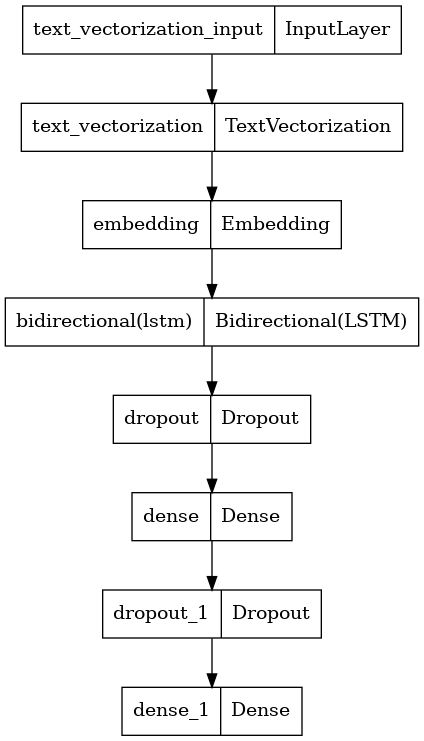

In [22]:
keras.utils.plot_model(model, "sentiment_classifier.png")

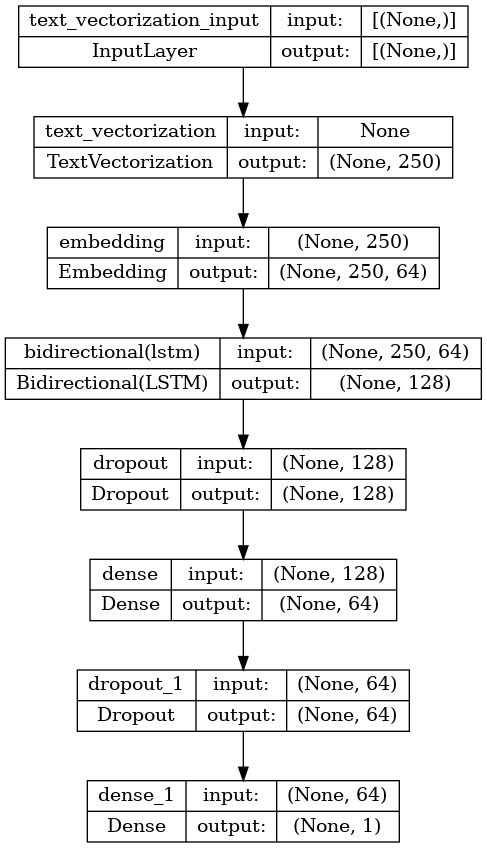

In [23]:
keras.utils.plot_model(model, "sentiment_classifier_with_shape_info.png", show_shapes=True)

In [24]:
epochs = 30

early_stopping = EarlyStopping(monitor='val_loss', mode='min', patience=25, verbose=1)
mc = ModelCheckpoint ('best_model.tf', monitor='val_loss', mode='min', save_best_only=True)

history = model.fit(
    X_train_ds, y_train_ds,
    epochs=epochs,
    validation_data=(X_val_ds, y_val_ds),
    callbacks=[early_stopping, mc],
    verbose=1)

Epoch 1/30
215/215 [==============================] - 56s 202ms/step - loss: 0.5180 - accuracy: 0.7319 - val_loss: 0.4558 - val_accuracy: 0.7835
Epoch 2/30
215/215 [==============================] - 6s 29ms/step - loss: 0.3073 - accuracy: 0.8737 - val_loss: 0.4963 - val_accuracy: 0.7835
Epoch 3/30
215/215 [==============================] - 5s 23ms/step - loss: 0.1997 - accuracy: 0.9232 - val_loss: 0.6375 - val_accuracy: 0.7808
Epoch 4/30
215/215 [==============================] - 5s 24ms/step - loss: 0.1261 - accuracy: 0.9510 - val_loss: 0.8259 - val_accuracy: 0.7572
Epoch 5/30
215/215 [==============================] - 4s 17ms/step - loss: 0.0897 - accuracy: 0.9656 - val_loss: 0.9472 - val_accuracy: 0.7598
Epoch 6/30
215/215 [==============================] - 4s 16ms/step - loss: 0.0594 - accuracy: 0.9746 - val_loss: 1.3116 - val_accuracy: 0.7730
Epoch 7/30
215/215 [==============================] - 4s 18ms/step - loss: 0.0479 - accuracy: 0.9775 - val_loss: 1.4234 - val_accuracy: 0.74

<function matplotlib.pyplot.show(close=None, block=None)>

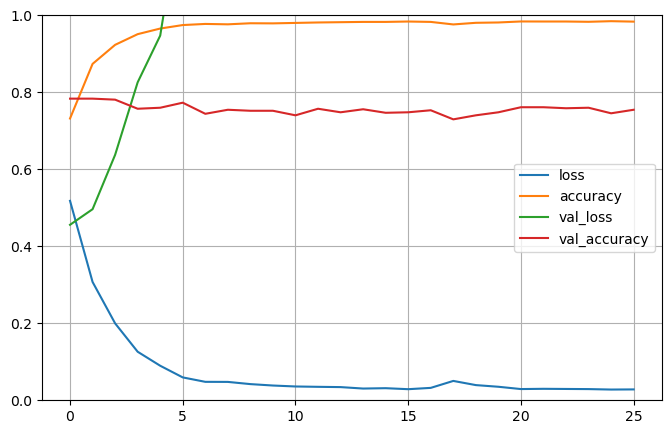

In [25]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show

In [26]:
len(history.history['loss']) 

26

In [27]:
probability_model = keras.Sequential([
                        model, 
                        layers.Activation('sigmoid')
                        ])

In [28]:
y_pred = probability_model.predict(X_val_ds)
y_pred = y_pred.flatten()

24/24 [==============================] - 3s 5ms/step


In [29]:
y_pred = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min())
y_pred = np.where(y_pred > 0.5, 1, 0)
y_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,

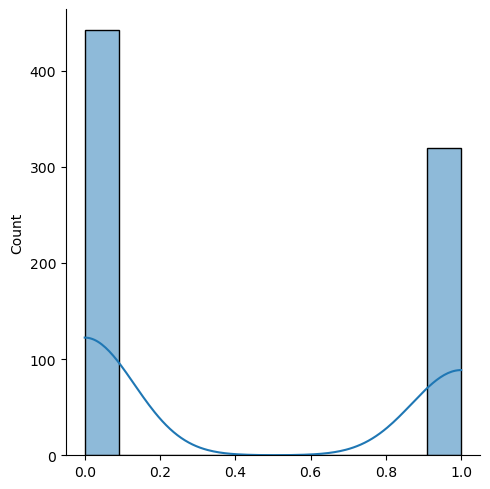

In [30]:
sns.displot(y_pred, kde=True)

In [31]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, y_pred)

0.7559055118110236

In [32]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_val, y_pred)

array([[341,  85],
       [101, 235]])

In [33]:
model.save('tweet_model')

Make predictions on test set

In [34]:
predictions = probability_model.predict(X_test_ds)
predictions = predictions.flatten()

102/102 [==============================] - 0s 4ms/step


In [35]:
predictions = (predictions - predictions.min()) / (predictions.max() - predictions.min())
predictions = np.where(predictions > 0.5, 1, 0)
predictions

array([1, 0, 1, ..., 1, 1, 1])

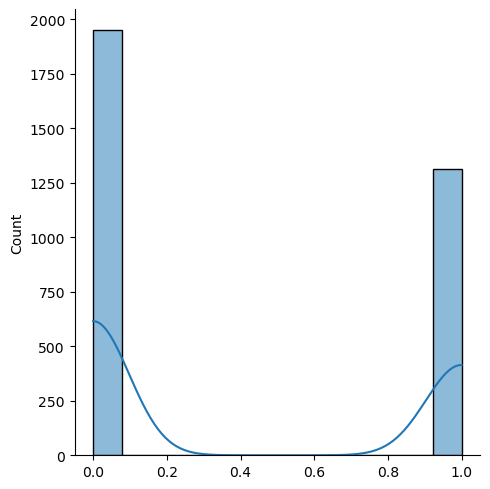

In [36]:
sns.displot(predictions, kde=True)

In [37]:
count_pred = np.unique(predictions, return_counts=True)
count_pred

(array([0, 1]), array([1950, 1313]))

Prepare submission

In [38]:

submission['target'] = predictions
submission.to_csv('submission.csv',index=False) # writing data to a CSV file
submission = pd.read_csv("submission.csv")
submission


,id,target
0,0,1
1,2,0
2,3,1
3,9,0
4,11,1
...,...,...
3258,10861,0
3259,10865,1
3260,10868,1
3261,10874,1
